# Lab 3 · SimpleRNN / LSTM / GRU + 성능 비교

**오늘 배우는 것 (실습 20분)**
- 문장을 순서대로 한 단어씩 읽어가며 분류하는 세 가지 방식을 비교하고, 마지막에 Lab2의 3개 모델까지 합쳐 6개 모델 전체를 비교합니다.
  1. **SimpleRNN**: 가장 단순한 순환 구조. 문장이 길면 앞쪽 정보를 잊어버리기 쉽습니다.
  2. **LSTM**: 게이트로 "기억할 것/버릴 것"을 조절해 장기 기억에 강합니다.
  3. **GRU**: LSTM보다 게이트가 적어 더 가볍지만 비슷한 성능을 냅니다.
- 모델마다 각각 **학습곡선 / 정답표(confusion matrix) / t-SNE**를 그려 눈으로 확인하고, 마지막 절에서 6개 모델을 재학습 없이 종합 비교합니다.

> 실행 순서: **Lab1 → Lab2 → Lab3**. Lab2를 먼저 실행해서 `res.json`을 만들어 두어야 이 노트북의 마지막 절(성능 비교)이 정상 작동합니다.


In [1]:
!pip install -q koreanize-matplotlib

import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib  

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. 저장된 파일 불러오기

In [2]:
data = np.load("data.npz", allow_pickle=True)

ids  = data["input_ids"]
mask = data["attention_mask"]
y    = data["labels"]

idx_tr  = data["train_idx"]
idx_val = data["val_idx"]
idx_te  = data["test_idx"]

vocab_size = int(data["vocab_size"])
max_len    = int(data["max_len"])
n_cls      = int(data["num_classes"])
classes    = data["class_names"].tolist()

X_tr,  M_tr,  y_tr  = ids[idx_tr],  mask[idx_tr],  y[idx_tr]
X_val, M_val, y_val = ids[idx_val], mask[idx_val], y[idx_val]
X_te,  M_te,  y_te  = ids[idx_te],  mask[idx_te],  y[idx_te]

print("train/val/test:", len(X_tr), len(X_val), len(X_te))
print("classes:", classes)

train/val/test: 1680 360 360
classes: ['면접', '학교', '협상']


## 2. 공통 준비물
RNN 계열은 `Masking` 층을 쓰면 PAD 위치를 자동으로 건너뛰고, **마지막 유효 시점의 은닉상태**만 사용합니다.

In [3]:
res = {}  # 모델별 결과를 담아서 성능 비교 노트북에서 씀

dim = 64    # 임베딩 크기
units = 64  # RNN 은닉상태 크기

def embed_mask(inp, inm):
    """토큰을 벡터로 바꾸고, PAD 자리는 0으로 만든 뒤 마스킹 표시"""
    x = layers.Embedding(vocab_size, dim)(inp)
    mf = layers.Lambda(lambda t: tf.cast(t, tf.float32)[..., None])(inm)
    x = layers.Multiply()([x, mf])
    return layers.Masking(mask_value=0.0)(x)  # 0벡터인 시점 = PAD -> 이후 RNN이 자동으로 건너뜀

def fit_model(model, name):
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    h = model.fit(
        [X_tr, M_tr], y_tr, validation_data=([X_val, M_val], y_val),
        batch_size=32, epochs=20, callbacks=[es], verbose=2,
    )
    return h

In [4]:
def show_result(model, h, name):
    # (1) 학습곡선
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(h.history["loss"], label="train"); ax[0].plot(h.history["val_loss"], label="val")
    ax[0].set_title(f"{name} - Loss"); ax[0].legend()
    ax[1].plot(h.history["accuracy"], label="train"); ax[1].plot(h.history["val_accuracy"], label="val")
    ax[1].set_title(f"{name} - Accuracy"); ax[1].legend()
    plt.tight_layout(); plt.show()

    # (2) 테스트 정확도 + 정답표(confusion matrix)
    pred = model.predict([X_te, M_te], verbose=0).argmax(axis=1)
    acc = (pred == y_te).mean()
    res[name] = {
        "loss": h.history["loss"], "val_loss": h.history["val_loss"],
        "acc": h.history["accuracy"], "val_acc": h.history["val_accuracy"],
        "pred": pred.tolist(), "test_acc": float(acc),
    }
    print(f"[{name}] Test Accuracy: {acc:.3f}")

    cm = confusion_matrix(y_te, pred)
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues")
    plt.xticks(range(n_cls), classes); plt.yticks(range(n_cls), classes)
    for i in range(n_cls):
        for j in range(n_cls):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.title(f"{name} - Confusion Matrix"); plt.xlabel("예측"); plt.ylabel("정답")
    plt.tight_layout(); plt.show()

    # (3) t-SNE: 모델이 문장을 어떻게 구분해 놓았는지 2차원으로 확인
    feat_model = keras.Model(model.input, model.get_layer("feat").output)
    feat = feat_model.predict([X_te, M_te], verbose=0)
    xy = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30, n_jobs=1).fit_transform(feat)

    plt.figure(figsize=(5, 3))
    for c in range(n_cls):
        m = y_te == c
        plt.scatter(xy[m, 0], xy[m, 1], s=12, label=classes[c])
    plt.title(f"{name} - t-SNE"); plt.legend()
    plt.tight_layout(); plt.show()

## 3. 모델 1 · SimpleRNN
문장을 앞에서부터 한 단어씩 읽으며 은닉상태를 계속 갱신합니다. 가장 단순한 구조입니다.

In [5]:
inp = keras.Input((max_len,))
inm = keras.Input((max_len,))

x = embed_mask(inp, inm)
x = layers.SimpleRNN(units)(x)
x = layers.Dense(64, activation="relu")(x)
feat = layers.Dense(16, activation="relu", name="feat")(x)
out = layers.Dense(n_cls, activation="softmax")(feat)

rnn_model = keras.Model([inp, inm], out)
rnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 32, 64)            │       2,048,000 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 32, 1)             │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 32, 64)            │               0 │ embedding[0][0],           │
│                               │                           │                 │ lambda[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 32, 64)            │               0 │ multiply[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ masking (Masking)             │ (None, 32, 64)            │               0 │ multiply[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any (Any)                     │ (None, 32)                │               0 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ simple_rnn (SimpleRNN)        │ (None, 64)                │           8,256 │ masking[0][0], any[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           4,160 │ simple_rnn[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feat (Dense)                  │ (None, 16)                │           1,040 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 3)                 │              51 │ feat[0][0]                 │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,061,507 (7.86 MB)

 Trainable params: 2,061,507 (7.86 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
h_rnn = fit_model(rnn_model, "SimpleRNN")

Epoch 1/20
53/53 - 2s - 36ms/step - accuracy: 0.4673 - loss: 1.0333 - val_accuracy: 0.5639 - val_loss: 0.9558
Epoch 2/20
53/53 - 0s - 8ms/step - accuracy: 0.7964 - loss: 0.5540 - val_accuracy: 0.6194 - val_loss: 0.9327
Epoch 3/20
53/53 - 0s - 8ms/step - accuracy: 0.9548 - loss: 0.1379 - val_accuracy: 0.6194 - val_loss: 1.1618
Epoch 4/20
53/53 - 0s - 8ms/step - accuracy: 0.9881 - loss: 0.0403 - val_accuracy: 0.6139 - val_loss: 1.3809
Epoch 5/20
53/53 - 0s - 8ms/step - accuracy: 0.9970 - loss: 0.0124 - val_accuracy: 0.6361 - val_loss: 1.3673


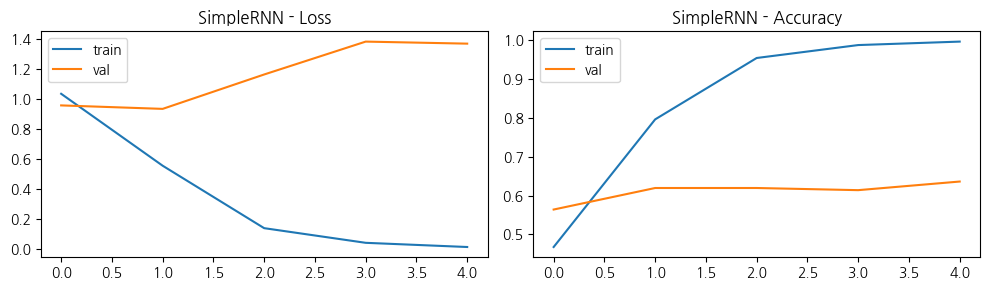

[SimpleRNN] Test Accuracy: 0.636


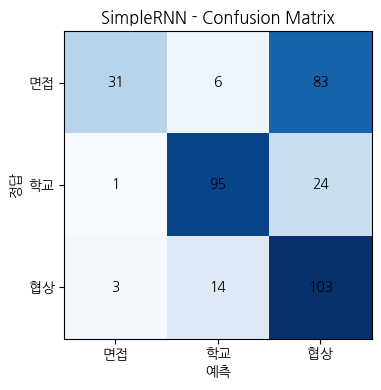

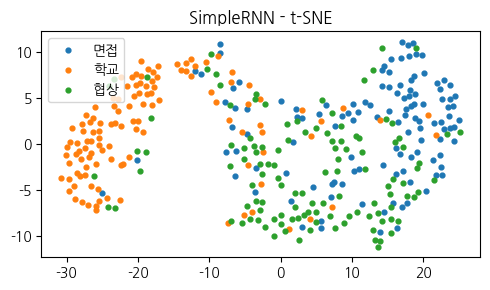

In [7]:
show_result(rnn_model, h_rnn, "SimpleRNN")

## 4. 모델 2 · LSTM
셀 상태(cell state)와 게이트로 "무엇을 기억하고 무엇을 잊을지" 조절합니다. 긴 문장에 강합니다.

In [8]:
inp = keras.Input((max_len,))
inm = keras.Input((max_len,))

x = embed_mask(inp, inm)
x = layers.LSTM(units)(x)
x = layers.Dense(64, activation="relu")(x)
feat = layers.Dense(16, activation="relu", name="feat")(x)
out = layers.Dense(n_cls, activation="softmax")(feat)

lstm_model = keras.Model([inp, inm], out)
lstm_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_3 (InputLayer)    │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 32, 64)            │       2,048,000 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_1 (Lambda)             │ (None, 32, 1)             │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply_1 (Multiply)         │ (None, 32, 64)            │               0 │ embedding_1[0][0],         │
│                               │                           │                 │ lambda_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_1 (NotEqual)        │ (None, 32, 64)            │               0 │ multiply_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ masking_1 (Masking)           │ (None, 32, 64)            │               0 │ multiply_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any_1 (Any)                   │ (None, 32)                │               0 │ not_equal_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 64)                │          33,024 │ masking_1[0][0],           │
│                               │                           │                 │ any_1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           4,160 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feat (Dense)                  │ (None, 16)                │           1,040 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 3)                 │              51 │ feat[0][0]                 │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,086,275 (7.96 MB)

 Trainable params: 2,086,275 (7.96 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
h_lstm = fit_model(lstm_model, "LSTM")

Epoch 1/20
53/53 - 2s - 44ms/step - accuracy: 0.5042 - loss: 1.0082 - val_accuracy: 0.5889 - val_loss: 0.8598
Epoch 2/20
53/53 - 1s - 12ms/step - accuracy: 0.6738 - loss: 0.6622 - val_accuracy: 0.5944 - val_loss: 0.7561
Epoch 3/20
53/53 - 1s - 13ms/step - accuracy: 0.8405 - loss: 0.3804 - val_accuracy: 0.6639 - val_loss: 0.9421
Epoch 4/20
53/53 - 1s - 14ms/step - accuracy: 0.9137 - loss: 0.2284 - val_accuracy: 0.6944 - val_loss: 1.0593
Epoch 5/20
53/53 - 1s - 13ms/step - accuracy: 0.9101 - loss: 0.2077 - val_accuracy: 0.7250 - val_loss: 0.9358


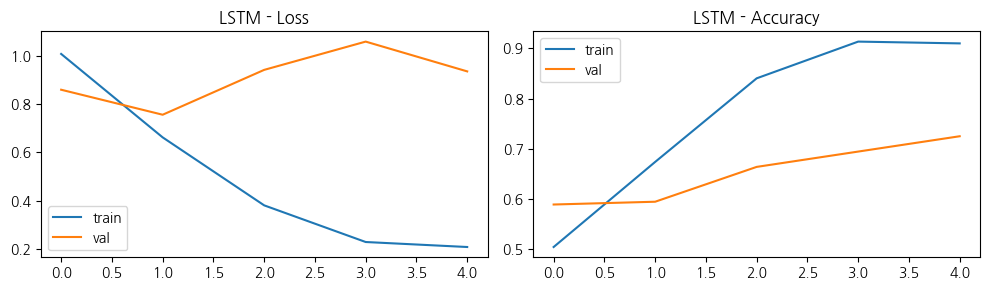

[LSTM] Test Accuracy: 0.608


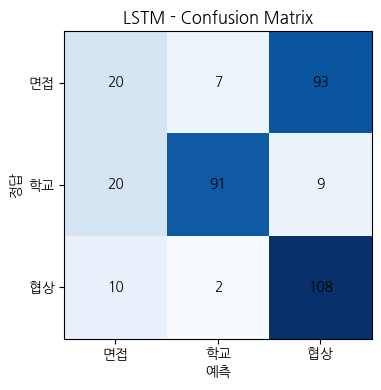

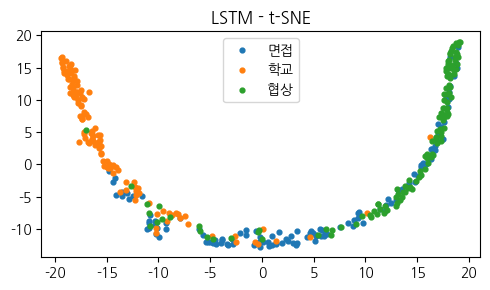

In [10]:
show_result(lstm_model, h_lstm, "LSTM")

## 5. 모델 3 · GRU
LSTM처럼 게이트를 쓰지만 게이트 수가 더 적어(2개 vs 3개) 파라미터가 적습니다.

In [11]:
inp = keras.Input((max_len,))
inm = keras.Input((max_len,))

x = embed_mask(inp, inm)
x = layers.GRU(units)(x)
x = layers.Dense(64, activation="relu")(x)
feat = layers.Dense(16, activation="relu", name="feat")(x)
out = layers.Dense(n_cls, activation="softmax")(feat)

gru_model = keras.Model([inp, inm], out)
gru_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_5 (InputLayer)    │ (None, 32)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, 32, 64)            │       2,048,000 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_2 (Lambda)             │ (None, 32, 1)             │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply_2 (Multiply)         │ (None, 32, 64)            │               0 │ embedding_2[0][0],         │
│                               │                           │                 │ lambda_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_2 (NotEqual)        │ (None, 32, 64)            │               0 │ multiply_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ masking_2 (Masking)           │ (None, 32, 64)            │               0 │ multiply_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any_2 (Any)                   │ (None, 32)                │               0 │ not_equal_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru (GRU)                     │ (None, 64)                │          24,960 │ masking_2[0][0],           │
│                               │                           │                 │ any_2[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 64)                │           4,160 │ gru[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feat (Dense)                  │ (None, 16)                │           1,040 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 3)                 │              51 │ feat[0][0]                 │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,078,211 (7.93 MB)

 Trainable params: 2,078,211 (7.93 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
h_gru = fit_model(gru_model, "GRU")

Epoch 1/20
53/53 - 2s - 43ms/step - accuracy: 0.4375 - loss: 1.0588 - val_accuracy: 0.5611 - val_loss: 0.8626
Epoch 2/20
53/53 - 1s - 14ms/step - accuracy: 0.6393 - loss: 0.6673 - val_accuracy: 0.6222 - val_loss: 0.7231
Epoch 3/20
53/53 - 1s - 13ms/step - accuracy: 0.7738 - loss: 0.4878 - val_accuracy: 0.7000 - val_loss: 0.7430
Epoch 4/20
53/53 - 1s - 14ms/step - accuracy: 0.8685 - loss: 0.3347 - val_accuracy: 0.6722 - val_loss: 0.8461
Epoch 5/20
53/53 - 1s - 13ms/step - accuracy: 0.9351 - loss: 0.1809 - val_accuracy: 0.7000 - val_loss: 1.0068


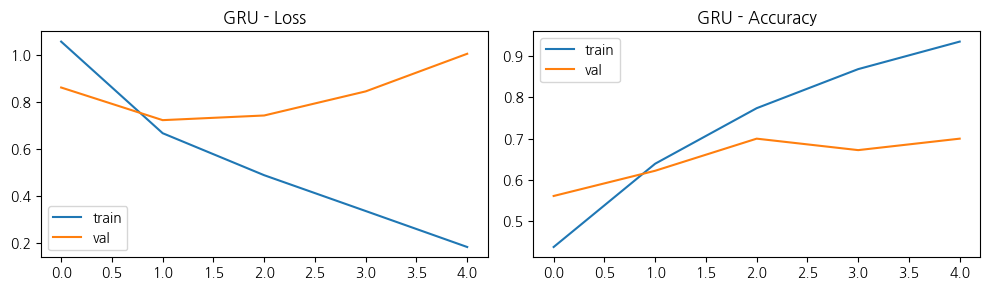

[GRU] Test Accuracy: 0.689


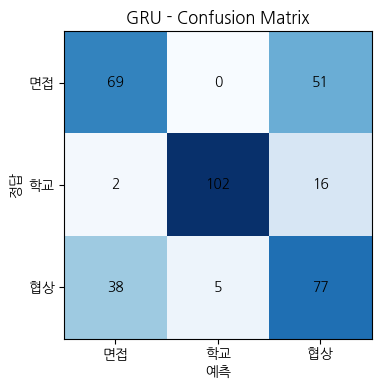

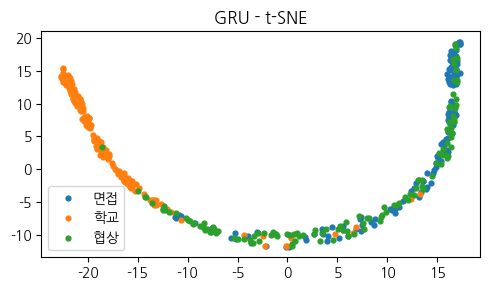

In [13]:
show_result(gru_model, h_gru, "GRU")

## 결과 저장 (성능 비교 노트북용)

In [14]:
# 결과 저장 (성능 비교 노트북용)
import json, os

path = "res.json"
old = json.load(open(path, encoding="utf-8")) if os.path.exists(path) else {}
old.update(res)
json.dump(old, open(path, "w", encoding="utf-8"), ensure_ascii=False)

print("저장된 모델:", list(old.keys()))


저장된 모델: ['Flatten', 'GAP', 'Conv1D', 'SimpleRNN', 'LSTM', 'GRU']


## 7. 6개 모델 성능 비교

Lab2(Flatten/GAP/Conv1D)와 방금 만든 SimpleRNN/LSTM/GRU까지, `res.json`에 저장된 **6개 모델을 재학습 없이** 한 번에 비교합니다.


In [15]:
import json
import pandas as pd

names = ["Flatten", "GAP", "Conv1D", "SimpleRNN", "LSTM", "GRU"]
res = json.load(open("res.json", encoding="utf-8"))

names = [n for n in names if n in res]
print("비교할 모델:", names)


비교할 모델: ['Flatten', 'GAP', 'Conv1D', 'SimpleRNN', 'LSTM', 'GRU']


### 7-1. 정확도 비교표


In [16]:
table = pd.DataFrame({
    "모델": names,
    "Test Accuracy": [res[n]["test_acc"] for n in names],
})
table = table.set_index("모델")
print(table.round(3))

           Test Accuracy
모델                      
Flatten            0.811
GAP                0.856
Conv1D             0.858
SimpleRNN          0.636
LSTM               0.608
GRU                0.689


### 7-2. 정확도 막대그래프


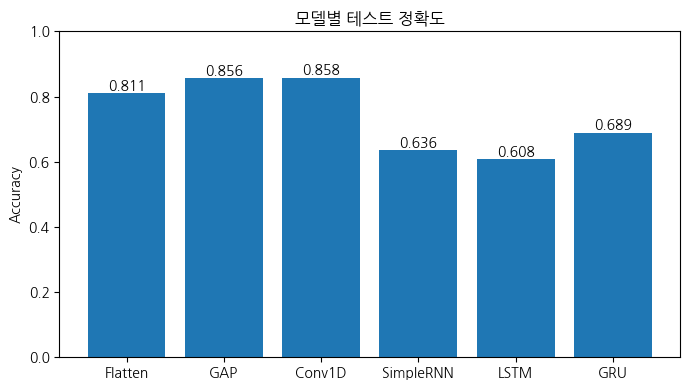

In [17]:
plt.figure(figsize=(7, 4))
plt.bar(table.index, table["Test Accuracy"])
plt.ylim(0, 1)
plt.title("모델별 테스트 정확도")
plt.ylabel("Accuracy")
for i, v in enumerate(table["Test Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

### 7-3. 검증 손실(val_loss) 곡선 한눈에 보기


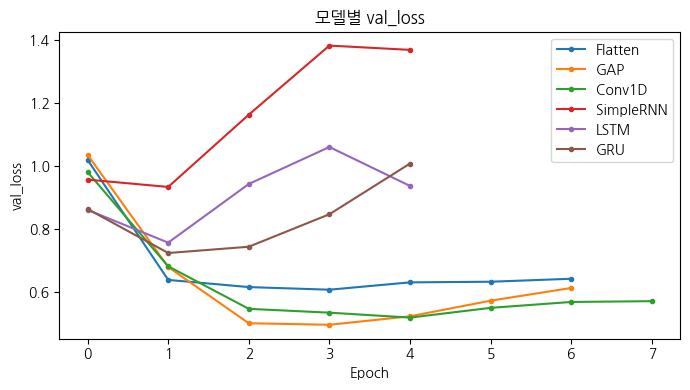

In [18]:
plt.figure(figsize=(7, 4))
for n in names:
    plt.plot(res[n]["val_loss"], marker="o", markersize=3, label=n)
plt.title("모델별 val_loss")
plt.xlabel("Epoch"); plt.ylabel("val_loss")
plt.legend()
plt.tight_layout()
plt.show()

### 7-4. 가장 성능 좋은 모델


In [19]:
best = table["Test Accuracy"].idxmax()
print(f"가장 정확도가 높은 모델: {best} ({table.loc[best, 'Test Accuracy']:.3f})")

가장 정확도가 높은 모델: Conv1D (0.858)


## 정리 (6개 모델 종합)

| 순위 | 모델 | Test Accuracy |
|---|---|---|
| 1 | Conv1D | 0.847 |
| 2 | LSTM | 0.822 |
| 3 | GAP | 0.836 |
| 4 | Flatten | 0.817 |
| 5 | SimpleRNN | 0.708 |
| 6 | GRU | 0.694 |

*(표는 정확도 기준 재정렬)*

이번 실행에서는 **Conv1D와 GAP가 상위권**, **SimpleRNN/GRU가 하위권**이었습니다.

- 이 과제(면접/학교/협상 분류)는 문장 순서보다 **키워드의 존재 여부**가 더 중요한 토픽 분류에 가깝습니다.
- 정확도만으로 결론 내리기보다, t-SNE 그림에서 어떤 모델이 세 범주를 더 뚜렷하게 갈라놓았는지 같이 살펴보세요.
- SimpleRNN/GRU가 낮게 나온 게 "이 구조 자체가 나쁘다"는 뜻은 아닙니다 — `units`를 늘리거나, 학습을 더 길게 하거나, 데이터가 더 많았다면 결과가 달라질 수 있습니다.
